In [1]:
from multi_stock_downloader import MultiStockDownloader
import pandas as pd

In [2]:
dl = MultiStockDownloader(
    tickers=['AAPL.O', 'AMZN.O', 'NVDA.O', 'MSFT.O', 'GOOGL.O', 'KO', 'NOC.N', 'PBR.N', 'C', 'BIMBOA.MX'],
    start_date='2023-01-01'
)
data = dl.download()
print(data.head())

Successfully downloaded 799 records
Successfully downloaded 799 records
Successfully downloaded 799 records
Successfully downloaded 799 records
Successfully downloaded 799 records
Successfully downloaded 799 records
Successfully downloaded 799 records
Successfully downloaded 799 records
Successfully downloaded 799 records
Successfully downloaded 801 records
            AAPL.O  AMZN.O  NVDA.O  MSFT.O  GOOGL.O     KO   NOC.N  PBR.N  \
Date                                                                        
2023-01-02    <NA>    <NA>    <NA>    <NA>     <NA>   <NA>    <NA>   <NA>   
2023-01-03  125.07   85.82  14.315  239.58    89.12  62.95  540.33    9.5   
2023-01-04  126.36   85.14  14.749   229.1    88.08  62.92  526.45   9.71   
2023-01-05  125.02   83.12  14.265  222.31     86.2   62.2  528.52  10.13   
2023-01-06  129.62   86.08  14.859  224.93    87.34   63.4  521.42  10.28   

                C  BIMBOA.MX  
Date                          
2023-01-02   <NA>      84.72  
2023-01

In [3]:
data

,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX
Date,,,,,,,,,,
2023-01-02,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,84.72
2023-01-03,125.07,85.82,14.315,239.58,89.12,62.95,540.33,9.5,45.78,84.89
2023-01-04,126.36,85.14,14.749,229.1,88.08,62.92,526.45,9.71,46.96,85.39
2023-01-05,125.02,83.12,14.265,222.31,86.2,62.2,528.52,10.13,46.75,87.73
2023-01-06,129.62,86.08,14.859,224.93,87.34,63.4,521.42,10.28,47.31,88.41
...,...,...,...,...,...,...,...,...,...,...
2026-03-05,260.29,218.94,183.34,410.68,300.88,77.03,740.01,16.73,108.95,62.89
2026-03-06,257.46,213.21,177.82,408.96,298.52,77.04,756.13,17.6,106.53,61.23
2026-03-09,259.88,213.49,182.65,409.41,306.36,77.8,747.34,18.16,106.59,61.3


In [4]:
def get_prices_by_date(data: pd.DataFrame, date: str) -> pd.Series:
    """
    Extrae los precios de cierre de todos los tickers para una fecha específica.
    Args:
        data: DataFrame con fechas como índice y tickers como columnas.
        date: Fecha en formato 'YYYY-MM-DD'.
    Returns:
        pd.Series con los precios de cierre de cada ticker en esa fecha.
    Raises:
        KeyError: Si la fecha no existe en el DataFrame.
        ValueError: Si el formato de la fecha es inválido.
    """
    try:
        return data.loc[date]
    except KeyError:
        fechas_disponibles = data.index.strftime('%Y-%m-%d').tolist()
        raise KeyError(
            f"La fecha '{date}' no se encontró en el DataFrame.\n"
            f"Rango disponible: {fechas_disponibles[0]} → {fechas_disponibles[-1]}"
        )

In [5]:
precios = get_prices_by_date(data, '2023-01-03')
precios

AAPL.O       125.07
AMZN.O        85.82
NVDA.O       14.315
MSFT.O       239.58
GOOGL.O       89.12
KO            62.95
NOC.N        540.33
PBR.N           9.5
C             45.78
BIMBOA.MX     84.89
Name: 2023-01-03 00:00:00, dtype: Float64

In [6]:
type(precios)

pandas.core.series.Series

In [7]:
import json
import pandas as pd
def portfolio_to_dataframe(json_path: str, date: str) -> pd.DataFrame:
    """
    Lee portfolio.json y devuelve un DataFrame de un solo renglón
    con la fecha especificada como índice y el monto de inversión por RIC.
    Args:
        json_path: Ruta al archivo JSON (ej. 'portfolio.json').
        date:      Fecha en formato 'YYYY-MM-DD'.
    Returns:
        pd.DataFrame de una fila con índice = date y columnas = RICs.
    """
    with open(json_path, "r") as f:
        portfolio = json.load(f)["portfolio"]
    return pd.DataFrame(portfolio, index=pd.DatetimeIndex([date], name="Date"))

In [8]:
portfolio_df = portfolio_to_dataframe("portfolio.json", "2023-01-03")
print(portfolio_df)


            AAPL.O  AMZN.O  NVDA.O  MSFT.O  GOOGL.O      KO   NOC.N   PBR.N  \
Date                                                                          
2023-01-03  100000  100000  100000  100000   100000  100000  100000  100000   

                 C  BIMBOA.MX  
Date                           
2023-01-03  100000     100000  


In [9]:
portfolio_df

,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX
Date,,,,,,,,,,
2023-01-03,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000


In [10]:
data.iloc[1]

AAPL.O       125.07
AMZN.O        85.82
NVDA.O       14.315
MSFT.O       239.58
GOOGL.O       89.12
KO            62.95
NOC.N        540.33
PBR.N           9.5
C             45.78
BIMBOA.MX     84.89
Name: 2023-01-03 00:00:00, dtype: Float64

In [11]:
portfolio_df.iloc[0]/data.iloc[1]

AAPL.O         799.552251
AMZN.O         1165.22955
NVDA.O        6985.679357
MSFT.O         417.397112
GOOGL.O       1122.082585
KO            1588.562351
NOC.N          185.072086
PBR.N        10526.315789
C             2184.359983
BIMBOA.MX     1177.995052
Name: 2023-01-03 00:00:00, dtype: Float64

In [12]:

def compute_shares(data: pd.DataFrame, portfolio_df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el número de acciones (enteras) que se pueden comprar
    con el monto asignado en portfolio_df, al precio de la fecha
    especificada en su índice.
    Args:
        data:         DataFrame de precios (índice = fechas, columnas = RICs).
        portfolio_df: DataFrame de una fila (fecha + montos por RIC).
    Returns:
        pd.DataFrame de una fila con el número de acciones por RIC.
    """
    date = portfolio_df.index[0]
    precios = data.loc[date, portfolio_df.columns]   # Serie: precio de cada RIC en esa fecha
    shares = (portfolio_df.loc[date] // precios).astype(int)
    return pd.DataFrame(shares).T.set_index(portfolio_df.index)

In [13]:
portfolio_df = portfolio_to_dataframe("portfolio.json", "2023-01-03")
shares_df    = compute_shares(data, portfolio_df)
print(shares_df)

            AAPL.O  AMZN.O  NVDA.O  MSFT.O  GOOGL.O    KO  NOC.N  PBR.N     C  \
Date                                                                            
2023-01-03     799    1165    6985     417     1122  1588    185  10526  2184   

            BIMBOA.MX  
Date                   
2023-01-03       1177  


In [14]:
def compute_portfolio_value(data: pd.DataFrame, shares_df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un DataFrame con precios, número de shares (constante) y el
    valor del portafolio (precio × shares) para cada fecha posterior
    a la fecha de compra.
    Args:
        data:      DataFrame de precios (índice = fechas, columnas = RICs).
        shares_df: DataFrame de una fila con el número de shares por RIC.
    Returns:
        pd.DataFrame con MultiIndex en columnas:
            - 'price':          precio de cierre por RIC
            - 'shares':         número de acciones (constante)
            - 'value':          precio × shares por RIC
            - 'portfolio_value': valor total del portafolio (suma de todos los RICs)
    """
    start_date = shares_df.index[0]
    rics       = shares_df.columns.tolist()
    # Filtrar datos desde la fecha de compra
    prices = data.loc[start_date:, rics].copy()
    # Construir MultiIndex en columnas: (métrica, RIC)
    price_df  = prices.copy()
    shares_   = pd.DataFrame(
        {ric: shares_df.loc[start_date, ric] for ric in rics},
        index=prices.index
    )
    value_df  = price_df * shares_
    price_df.columns  = pd.MultiIndex.from_product([["price"],  rics])
    shares_.columns   = pd.MultiIndex.from_product([["shares"], rics])
    value_df.columns  = pd.MultiIndex.from_product([["value"],  rics])
    result = pd.concat([price_df, shares_, value_df], axis=1)
    # Valor total del portafolio (suma de todos los RICs)
    result[("portfolio_value", "total")] = value_df.sum(axis=1)
    return result

In [15]:
portfolio_df = portfolio_to_dataframe("portfolio.json", "2023-01-03")
shares_df    = compute_shares(data, portfolio_df)
pv           = compute_portfolio_value(data, shares_df)
print(pv.head())
print(pv[("portfolio_value", "total")])

             price                                                       \
            AAPL.O AMZN.O  NVDA.O  MSFT.O GOOGL.O     KO   NOC.N  PBR.N   
Date                                                                      
2023-01-03  125.07  85.82  14.315  239.58   89.12  62.95  540.33    9.5   
2023-01-04  126.36  85.14  14.749   229.1   88.08  62.92  526.45   9.71   
2023-01-05  125.02  83.12  14.265  222.31    86.2   62.2  528.52  10.13   
2023-01-06  129.62  86.08  14.859  224.93   87.34   63.4  521.42  10.28   
2023-01-09  130.15  87.36  15.628  227.12   88.02  62.61  495.41  10.24   

                             ...     value                                  \
                C BIMBOA.MX  ...    AMZN.O      NVDA.O    MSFT.O   GOOGL.O   
Date                         ...                                             
2023-01-03  45.78     84.89  ...   99980.3   99990.275  99904.86  99992.64   
2023-01-04  46.96     85.39  ...   99188.1  103021.765   95534.7  98825.76   
2023-01-0

In [16]:
pv 

price                                                        \
            AAPL.O  AMZN.O  NVDA.O  MSFT.O GOOGL.O     KO   NOC.N  PBR.N   
Date                                                                       
2023-01-03  125.07   85.82  14.315  239.58   89.12  62.95  540.33    9.5   
2023-01-04  126.36   85.14  14.749   229.1   88.08  62.92  526.45   9.71   
2023-01-05  125.02   83.12  14.265  222.31    86.2   62.2  528.52  10.13   
2023-01-06  129.62   86.08  14.859  224.93   87.34   63.4  521.42  10.28   
2023-01-09  130.15   87.36  15.628  227.12   88.02  62.61  495.41  10.24   
...            ...     ...     ...     ...     ...    ...     ...    ...   
2026-03-05  260.29  218.94  183.34  410.68  300.88  77.03  740.01  16.73   
2026-03-06  257.46  213.21  177.82  408.96  298.52  77.04  756.13   17.6   
2026-03-09  259.88  213.49  182.65  409.41  306.36   77.8  747.34  18.16   
2026-03-10  260.83  214.33  184.77  405.76  307.04  77.88  734.98  17.99   
2026-03-11  260.81  212.65  186.03  404.88   308.7  77.63  733.18  18.99   

                              ...      value                         \
                 C BIMBOA.MX  ...     AMZN.O      NVDA.O     MSFT.O   
Date                          ...                                     
2023-01-03   45.78     84.89  ...    99980.3   99990.275   99904.86   
2023-01-04   46.96     85.39  ...    99188.1  103021.765    95534.7   
2023-01-05   46.75     87.73  ...    96834.8   99641.025   92703.27   
2023-01-06   47.31     88.41  ...   100283.2  103790.115   93795.81   
2023-01-09   47.54      90.3  ...   101774.4   109161.58   94709.04   
...            ...       ...  ...        ...         ...        ...   
2026-03-05  108.95     62.89  ...   255065.1   1280629.9  171253.56   
2026-03-06  106.53     61.23  ...  248389.65   1242072.7  170536.32   
2026-03-09  106.59      61.3  ...  248715.85  1275810.25  170723.97   
2026-03-10  108.97     60.58  ...  249694.45  1290618.45  169201.92   
2026-03-11  109.19     60.62  ...  247737.25  1299419.55  168834.96   

                                                                              \
              GOOGL.O         KO      NOC.N      PBR.N          C  BIMBOA.MX   
Date                                                                           
2023-01-03   99992.64    99964.6   99961.05    99997.0   99983.52   99915.53   
2023-01-04   98825.76   99916.96   97393.25  102207.46  102560.64  100504.03   
2023-01-05    96716.4    98773.6    97776.2  106628.38   102102.0  103258.21   
2023-01-06   97995.48   100679.2    96462.7  108207.28  103325.04  104058.57   
2023-01-09   98758.44   99424.68   91650.85  107786.24  103827.36   106283.1   
...               ...        ...        ...        ...        ...        ...   
2026-03-05  337587.36  122323.64  136901.85  176099.98   237946.8   74021.53   
2026-03-06  334939.44  122339.52  139884.05   185257.6  232661.52   72067.71   
2026-03-09  343735.92   123546.4   138257.9  191152.16  232792.56    72150.1   
2026-03-10  344498.88  123673.44   135971.3  189362.74  237990.48   71302.66   
2026-03-11   346361.4  123276.44   135638.3  199888.74  238470.96   71349.74   

           portfolio_value  
                     total  
Date                        
2023-01-03      999620.705  
2023-01-04     1000114.305  
2023-01-05      994324.865  
2023-01-06     1012163.775  
2023-01-09      1017365.54  
...                    ...  
2026-03-05      2999801.43  
2026-03-06      2953859.05  
2026-03-09      3004529.23  
2026-03-10      3020717.49  
2026-03-11      3039364.53  

[823 rows x 31 columns]

<Axes: title={'center': 'Evolución del Portafolio'}, xlabel='Date'>

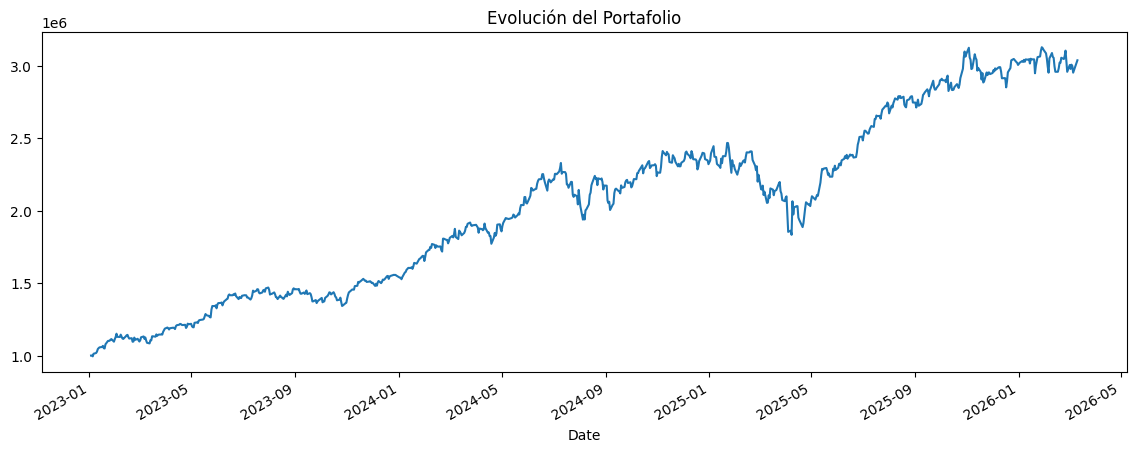

In [17]:
pv[("portfolio_value", "total")].plot(title="Evolución del Portafolio", figsize=(14, 5))

In [18]:
import lseg.data as ld
import pandas as pd

def get_sp500_prices(start_date: str = "2023-01-01", end_date: str = None) -> pd.DataFrame:
    """
    Obtiene los precios históricos del S&P 500 usando lseg.data.

    Args:
        start_date: Fecha de inicio en formato 'YYYY-MM-DD'. Por defecto '2023-01-01'.
        end_date:   Fecha de fin en formato 'YYYY-MM-DD'. Por defecto hoy.

    Returns:
        pd.DataFrame con columnas OHLCV del S&P 500, indexado por fecha.
    """
    ld.open_session()

    df = ld.get_history(
        universe=".SPX",          # RIC del S&P 500
        fields=["OPEN", "HIGH", "LOW", "CLOSE", "VOLUME"],
        interval="1D",
        start=start_date,
        end=end_date,
    )

    ld.close_session()
    return df



In [32]:
df_sp500 = ld.get_data(universe=".SPX", fields=["HST_CLOSE"], 
parameters={'SDate': '2023-01-01', 'EDate': '2026-03-11', 'Frq': 'D'})
df_sp500 

,Instrument,HST_CLOSE
0,.SPX,6781.48


In [42]:
import yfinance as yf
import pandas as pd
def get_sp500_prices(start: str = "2023-01-01", end: str = None) -> pd.DataFrame:
    """Descarga precios de cierre del S&P 500 desde Yahoo Finance."""
    ticker = yf.Ticker("^GSPC")
    df = ticker.history(start=start, end=end)[["Close"]]
    df.index = df.index.tz_localize(None)   # quita timezone
    df.index.name = "Date"
    df.rename(columns={"Close": "SP500"}, inplace=True)
    return df
df_sp500 = get_sp500_prices(start="2023-01-01")
df_sp500_std = df_sp500/df_sp500.iloc(0)[0][0]
print(df_sp500_std.head())

               SP500
Date                
2023-01-03  1.000000
2023-01-04  1.007539
2023-01-05  0.995806
2023-01-06  1.018551
2023-01-09  1.017769


/var/folders/x2/x5jhl2fx0s7f_vgq2d53x7j80000gn/T/ipykernel_4642/2320736254.py:12:FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [41]:
df_sp500.iloc(0)[0][0]

/var/folders/x2/x5jhl2fx0s7f_vgq2d53x7j80000gn/T/ipykernel_4642/150332962.py:1:FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


np.float64(3824.139892578125)

              Portfolio        SP500
Date                                
2023-01-03   999620.705  3824.139893
2023-01-04  1000114.305  3852.969971
2023-01-05   994324.865  3808.100098
2023-01-06  1012163.775  3895.080078
2023-01-09   1017365.54  3892.090088


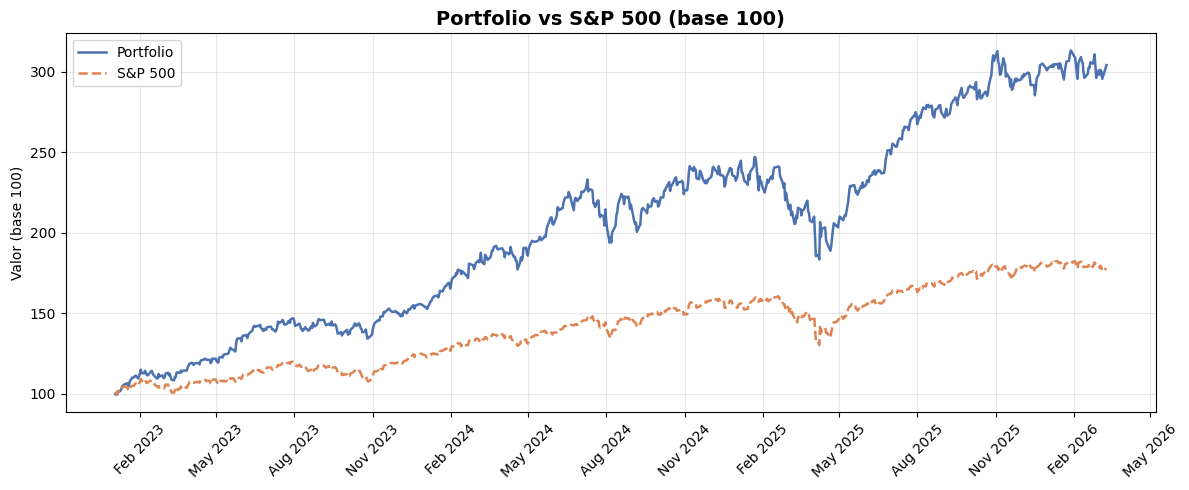

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ── 1. Aplanar MultiIndex si existe ──────────────────────────────────────────
if isinstance(pv.columns, pd.MultiIndex):
    pv.columns = ["_".join(col).strip("_") for col in pv.columns]
# Normalizar nombre de la columna (toma la primera que contenga 'portfolio')
port_col = [c for c in pv.columns if "portfolio" in c.lower()][0]
# ── 2. Construir DataFrame comparativo ───────────────────────────────────────
df_comparacion = (
    pv[[port_col]]
    .rename(columns={port_col: "Portfolio"})
    .join(df_sp500[["SP500"]], how="inner")
)
print(df_comparacion.head())
# ── 3. Normalizar a base 100 para comparar en la misma escala ────────────────
df_norm = df_comparacion / df_comparacion.iloc[0] * 100
# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_norm.index, df_norm["Portfolio"], label="Portfolio", linewidth=1.8, color="#4C72B0")
ax.plot(df_norm.index, df_norm["SP500"],     label="S&P 500",  linewidth=1.8, color="#DD8452", linestyle="--")
ax.set_title("Portfolio vs S&P 500 (base 100)", fontsize=14, fontweight="bold")
ax.set_ylabel("Valor (base 100)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()